# 3장 2강 종합 분석 실습: 퍼널·리텐션·개선 시나리오 통합 적용

실습문제

## 실습 목표

- Ravenstack의 실제 기록으로 시간순 퍼널과 가입 월별 리텐션을 계산한다.
- 전환율·리텐션 표와 그래프를 근거로 초기 가설을 검토한다.
- 교안의 네 가지 기준으로 개선 우선순위를 정한다.
- 이상 신호 → 개선안 → 기대 효과 → A/B 테스트 아이디어를 작성한다.

## 실습 환경 / 데이터

- Python / Colab, pandas, matplotlib. 필요 시 `%pip install pandas matplotlib`를 별도 셀에서 실행합니다.
- 첨부 Ravenstack 중 `accounts`, `subscriptions`, `feature_usage` CSV를 사용합니다. `(2)`가 붙은 파일명과 원래 파일명을 모두 지원합니다.
- `support_tickets`, `churn_events`도 제공된 동일 데이터셋의 일부지만 이번 교안의 퍼널·기능 사용 리텐션 계산에는 필요하지 않아 분석에 사용하지 않습니다.
- CSV를 노트북과 같은 폴더에 두거나 준비 코드의 `DATA_DIR`을 수정하세요.

### 분석 문제와 공통 기준

이번 실습은 **2024년 7~9월 가입한 전체 산업의 신규 계정**을 대상으로 합니다. 기존 파일의 DevTools 구독 상태 비교를, 교안의 가입 시점·시간순 행동 분석에 맞게 변경했습니다. 별도의 1강 답안 없이도 풀 수 있도록 문제와 가설을 아래에 제공합니다.

- 분석 문제: 신규 계정은 가입한 달에 기능 사용까지 얼마나 도달하며, 이후에도 사용하는가?
- 목표 지표: 가입 월 기능 사용 도달률 = 가입 월에 실제 사용한 계정 수 / 대상 가입 계정 수.
- 초기 가설: 가입→구독 시작보다 구독 시작→기능 사용 구간의 전환율이 낮을 것이다. 이후 기능 사용률은 매월 감소할 것이다. **분석 전 가설이며 실제 결과와 다를 수 있습니다.**
- 분석 단위는 `account_id`입니다. 한 계정의 여러 구독·사용 기록은 중복 계정으로 세지 않습니다.
- 실제 사용은 `usage_count > 0`, 사용일이 해당 구독 시작일 이상이며 종료일이 있으면 종료일 이하인 기록입니다. 가입 전 시작된 구독은 이 신규 가입 경로에서 제외합니다.
- 달은 달력 월입니다. 가입 월 말까지를 퍼널 관찰 기간으로 사용하므로 월말 가입자는 관찰 일수가 짧습니다. 동일한 가입 후 30일 지표와는 다릅니다.
- 파일의 최종 사용일을 분석 종료일로 사용하며, 그때까지의 로그가 제공되었다고 가정합니다. 로그가 없다는 것은 기록상 미사용이며 해지·영구 이탈을 뜻하지 않습니다.

| 컬럼 | 활용 |
|---|---|
| accounts: account_id, signup_date | 신규 계정과 가입 월 코호트 |
| subscriptions: subscription_id, account_id, start_date, end_date | 가입 이후 구독 시작 확인, 계정과 사용 기록 연결 |
| feature_usage: subscription_id, usage_date, usage_count | 실제 기능 사용과 사용 월 확인 |

| 구성 | 교안에 대응하는 내용 |
|---|---|
| 필수 1 | 1절: 시간순 퍼널, 전환율, 시각화, 가설 대조 |
| 필수 2 | 2절: 가입 월 코호트, 리텐션 곡선과 변화 해석 |
| 과제 1 | 3·4절: 네 기준의 우선순위 판단과 네 항목의 개선 시나리오 |

## 실습 준비

아래 코드는 공통으로 제공합니다. 데이터 불러오기, 분석 컬럼·결측치·자료형, 기초 통계량·분포를 확인하고 분석용 표를 준비하세요. 테이블 연결은 Ravenstack 구조에 맞춘 준비 과정이며 새로운 통계 기법을 요구하지 않습니다.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(".")
folders = [DATA_DIR, Path("upload"), Path("data"), Path("/content")]
data = {}
for name in ["accounts", "subscriptions", "feature_usage"]:
    names = [f"ravenstack_{name}(2).csv", f"ravenstack_{name}.csv"]
    path = next((d/f for f in names for d in folders if (d/f).exists()), None)
    if path is None:
        raise FileNotFoundError(f"{name} CSV를 올리거나 DATA_DIR을 수정하세요.")
    data[name] = pd.read_csv(path)
    print(path.name, data[name].shape)

accounts = data["accounts"][["account_id", "signup_date"]].copy()
subscriptions = data["subscriptions"][["subscription_id", "account_id", "start_date", "end_date"]].copy()
usage = data["feature_usage"][["subscription_id", "usage_date", "usage_count"]].copy()
for frame, cols in [(accounts, ["signup_date"]), (subscriptions, ["start_date", "end_date"]), (usage, ["usage_date"])]:
    for col in cols:
        frame[col] = pd.to_datetime(frame[col], errors="raise")
    print("\n분석 컬럼 예시:\n", frame.head(3).to_string(index=False))
    print("자료형:\n", frame.dtypes.to_string())
    print("결측치:\n", frame.isna().sum().to_string())
# end_date 결측은 종료일이 기록되지 않은 구독이므로 삭제하지 않습니다.
assert accounts.account_id.is_unique
assert subscriptions.subscription_id.is_unique
assert not accounts.isna().any().any()
assert not subscriptions.drop(columns="end_date").isna().any().any()
assert not usage.isna().any().any()
print("\n사용 횟수 기초 통계량:\n", usage.usage_count.describe().to_string())
print("가입 월별 계정 수:\n", accounts.groupby(accounts.signup_date.dt.to_period("M")).size().to_string())
analysis_end = usage.usage_date.max()
print("사용 기록 범위:", usage.usage_date.min().date(), "~", analysis_end.date())

target = accounts.loc[accounts.signup_date.between("2024-07-01", "2024-09-30")].copy()
target["cohort"] = target.signup_date.dt.to_period("M")
subs = subscriptions.merge(target, on="account_id", how="inner", validate="many_to_one")
excluded_subs = (subs.start_date < subs.signup_date).sum()
subs = subs.loc[subs.start_date >= subs.signup_date].copy()
events = usage.merge(subs, on="subscription_id", how="inner", validate="many_to_one")
valid = ((events.usage_count > 0) & (events.usage_date >= events.start_date)
         & (events.end_date.isna() | (events.usage_date <= events.end_date)))
excluded_events = (~valid).sum()
events = events.loc[valid].copy()
events["month_offset"] = ((events.usage_date.dt.year - events.signup_date.dt.year) * 12
                          + events.usage_date.dt.month - events.signup_date.dt.month)
print("\n대상 신규 계정 수:", len(target))
print("가입 전 시작으로 제외한 구독 수:", excluded_subs)
print("사용 조건을 충족하지 않아 제외한 연결 기록 수:", excluded_events)
print("코호트별 가입 계정 수:\n", target.groupby("cohort").size().to_string())


ravenstack_accounts.csv (500, 10)
ravenstack_subscriptions.csv (5000, 14)
ravenstack_feature_usage.csv (25000, 8)

분석 컬럼 예시:
 account_id signup_date
  A-2e4581  2024-10-16
  A-43a9e3  2023-08-17
  A-0a282f  2024-08-27
자료형:
 account_id                str
signup_date    datetime64[us]
결측치:
 account_id     0
signup_date    0

분석 컬럼 예시:
 subscription_id account_id start_date   end_date
       S-8cec59   A-3c1a3f 2023-12-23 2024-04-12
       S-0f6f44   A-9b9fe9 2024-06-11        NaT
       S-51c0d1   A-659280 2024-11-25        NaT
자료형:
 subscription_id               str
account_id                    str
start_date         datetime64[us]
end_date           datetime64[us]
결측치:
 subscription_id       0
account_id            0
start_date            0
end_date           4514

분석 컬럼 예시:
 subscription_id usage_date  usage_count
       S-0fcf7d 2023-07-27            9
       S-c25263 2023-08-07            9
       S-f29e7f 2023-12-07            9
자료형:
 subscription_id               str
usage_date  

---

## 필수 1 — 신규 계정의 가입 월 퍼널 분석

### 상황

가입한 달에 기능 사용까지 도달하지 못하는 구간을 찾으려고 합니다. 실제 데이터에 없는 화면 조회·온보딩 이벤트는 만들지 않습니다.

### 수행 사항

1. `target`, `subs`, `events`로 아래 세 단계의 고유 계정 수를 계산하세요.
   - 가입: 대상 계정 전체
   - 구독 시작: 가입일 이후이면서 가입 월 안에 구독이 시작된 계정
   - 기능 사용: 해당 구독에서 가입 월 안에 실제 사용한 계정
2. 이전 단계 대비 전환율·이탈률과 미도달 계정 수를 표로 만드세요. 첫 단계의 전환율·이탈률은 비교 대상이 없어 빈 값으로 둡니다.
3. 막대그래프로 단계별 계정 수를 표시하고 가장 낮은 전환율 구간을 찾으세요.
4. 가입 월 기능 사용 도달률도 계산하여 초기 가설과 대조하세요.

### 질문

Q1. 세 단계의 계정 수와 구간별 전환율·이탈률·미도달 수는 얼마인가요?

Q2. 가장 낮은 전환율 구간은 어디이며, 퍼널 초기 가설과 일치하나요?

Q3. 가입 월 기능 사용 도달률은 얼마이며, 마지막 구간 전환율과 분모가 어떻게 다른가요?

Q4. 왜 계정 수를 중복 제거해야 하며, 이 결과만으로 미사용 원인을 확정할 수 있나요?

### 체크 포인트

같은 분석 단위, 시간 순서, 이전 단계 분모, 데이터로 확인한 사실과 원인 가설의 구분.


중첩 확인(기능사용 ⊆ 구독시작 ⊆ 가입): True


,stage,account_count,step_conversion_pct,dropoff_pct,dropoff_count
0,가입,72,NaN,NaN,<NA>
1,구독 시작,52,72.2,27.8,20
2,기능 사용,5,9.6,90.4,47


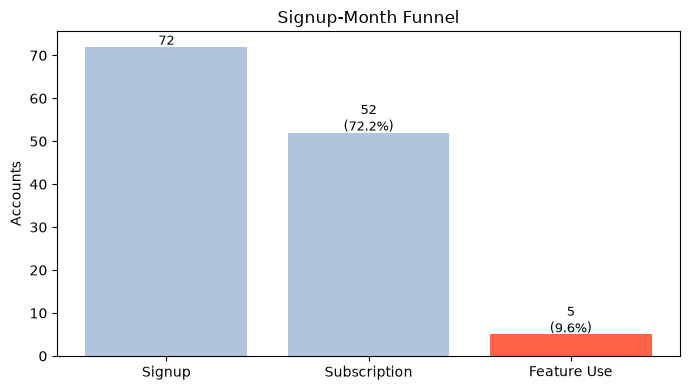

가장 낮은 전환 구간: 기능 사용 (9.6%)
가입 월 기능 사용 도달률: 5/72 = 6.9%


In [3]:
# 필수 1 풀이 코드를 작성하세요.
# 준비 코드의 target, subs, events를 활용하세요.

# ===== 1. 세 단계의 고유 계정 수 =====
# 1단계: 가입 — 대상 계정 전체
signup_ids = set(target["account_id"])

# 2단계: 구독 시작 — 가입 월 안에 구독이 시작된 계정
#   (subs는 준비 코드에서 이미 start_date >= signup_date로 걸러져 있음)
subs_in_month = subs.loc[
    subs["start_date"].dt.to_period("M") == subs["signup_date"].dt.to_period("M")
].copy()
subscribed_ids = set(subs_in_month["account_id"])

# 3단계: 기능 사용 — 그 구독에서 가입 월 안에 실제 사용한 계정
events_in_month = events.loc[
    (events["month_offset"] == 0)
    & (events["subscription_id"].isin(subs_in_month["subscription_id"]))
].copy()
used_ids = set(events_in_month["account_id"])

print("중첩 확인(기능사용 ⊆ 구독시작 ⊆ 가입):", used_ids <= subscribed_ids <= signup_ids)

# ===== 2. 전환율·이탈률·미도달 수 표 =====
funnel = pd.DataFrame({
    "stage": ["가입", "구독 시작", "기능 사용"],
    "account_count": [len(signup_ids), len(subscribed_ids), len(used_ids)],
})
prev = funnel["account_count"].shift(1)          # 이전 단계 계정 수 = 분모
funnel["step_conversion_pct"] = (funnel["account_count"] / prev * 100).round(1)
funnel["dropoff_pct"] = (100 - funnel["step_conversion_pct"]).round(1)
funnel["dropoff_count"] = (prev - funnel["account_count"]).astype("Int64")
display(funnel)

# ===== 3. 막대그래프 + 최저 전환 구간 =====
plt.figure(figsize=(7, 4))
bars = plt.bar(["Signup", "Subscription", "Feature Use"], funnel["account_count"],
               color=["lightsteelblue", "lightsteelblue", "tomato"])
for bar, cnt, conv in zip(bars, funnel["account_count"], funnel["step_conversion_pct"]):
    label = f"{cnt}" if pd.isna(conv) else f"{cnt}\n({conv}%)"
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, label, ha="center", fontsize=9)
plt.title("Signup-Month Funnel")
plt.ylabel("Accounts")
plt.tight_layout()
plt.show()

lowest = funnel.loc[funnel["step_conversion_pct"].idxmin()]
print(f"가장 낮은 전환 구간: {lowest['stage']} ({lowest['step_conversion_pct']}%)")

# ===== 4. 가입 월 기능 사용 도달률 =====
reach_rate = len(used_ids) / len(signup_ids) * 100
print(f"가입 월 기능 사용 도달률: {len(used_ids)}/{len(signup_ids)} = {reach_rate:.1f}%")


### 서술 답안

- 전환율(conversion_pct) : 현재 단계 계정 수 / 이전단계 계정 수 x 100 | 가입->구독은 52/72 = 72.2%, 구독->사용은 5/52 = 9.62%입니다. 구독 시작 계정 100개당 약 10개가 같은 달 실제 사용까지 도달한 비중
- 구간 이탈률(dropoff_pct) : 다음 단계에 도달하지 않은 비율 = 100-전환율 | 구독->사용의 90/.38%는 구독 시작 52개 중 47개가 가입 월 사용에 도달하지 않았다는 뜻. 구독 해지율이나 영구 이탈률이 아님
- 미도달수(not_pct) : 이전 단계 계정 수 - 현재 단계 계정 수 | 가입->구독은 72-52=20개, 구독->사용은 52-5=47개입니다. 비율과 달리 실제로 몇 계정이 해당 구간에 남아있는지 보여줌
- 전체 도달률 : 마지막 단계 계정 수 / 전체 가입 계정 수 x 100 | 5/72=6.94%입니다. 신규 가입 계정 전체 중 같은 달 기능 사용을 경험한 비중
- 병목 : 목표 행동으로 이어지는 단계별 흐름에서 전환이 특히 저조한 구간
- 구독 -> 사용 전환율이 9.62%로 낮고 미도달 수가 47건으로 우선 점검해야한다.



Q1. 세 단계의 계정 수와 구간별 전환율·이탈률·미도달 수는 얼마인가요?  
-> `가입 72건 -> 구독 시작 52건 -> 기능 사용 5건 -> 구독 전환율 72.22%, 이탈률 27.78%, 미도달 20건`  
-> `구독 -> 사용은 구독 전환율 9.62%, 이탈률 90.38%, 47건`
 
Q2. 가장 낮은 전환율 구간은 어디이며, 퍼널 초기 가설과 일치하나요?  
-> `구독 시작 -> 기능 사용 구간, 퍼널 초기 가설인 이 구간의 전환율이 낮을 것이라는 가설과 일치`

Q3. 가입 월 기능 사용 도달률은 얼마이며, 마지막 구간 전환율과 분모가 어떻게 다른가요?  
-> `6.94%, 전체 가입 72개가 분모, 마지막 구간 전환율은 전달 대비니까 52개가 분모`  

Q4. 왜 계정 수를 중복 제거해야 하며, 이 결과만으로 미사용 원인을 확정할 수 있나요?  
-> `한 계정에서 여러 구독을 사용하는 경우, 기능 자체가 어려워서, 또는 기능 자체가 너무 불친절한 버튼형식으로 되어있는 등`  
-> `원인은 명백하게 아직은 규정할 수 없음`

---

## 필수 2 — 가입 월별 기능 사용 리텐션 비교

### 상황

필수 1의 7·8·9월 가입 계정을 같은 가입 월 코호트로 묶습니다. 재방문을 직접 측정하는 로그인 로그가 없으므로 **해당 월의 실제 기능 사용을 재방문의 기준 행동**으로 사용합니다.

### 수행 사항

1. 코호트별 분모는 가입 계정 전체로 고정합니다. M0는 가입 시점의 기준 규모 100%이며 **가입 월 기능 사용률 100%라는 뜻이 아닙니다.** M1~M3는 가입 다음 달부터 3개월째까지, 해당 달에 실제 사용한 계정 수 / 코호트 가입 계정 수 × 100입니다.
2. 월별 사용 계정 수 표와 M0~M3 리텐션 표·선그래프를 만드세요. 사용 월과 가입 월의 차이는 준비 코드의 `month_offset`을 활용합니다.
3. M3 리텐션 최고·최저 코호트를 찾고, M1→M2·M2→M3 변화폭(%p)을 비교하세요.
4. 계속 감소하거나 안정되는지, 아니면 다른 패턴인지 실제 출력에 맞게 해석하세요.

이번 코호트는 모두 M3 월말까지 관찰 가능한지 먼저 확인합니다. 월별 사용자는 이전 달 사용자의 부분집합일 필요가 없으며, 중간에 사용하지 않다가 다시 사용한 계정도 셉니다. 아직 관찰하지 못한 달을 미사용 0명으로 채우면 안 됩니다.

### 질문

Q1. 코호트별 가입 계정 수와 M1~M3 실제 사용 계정 수·리텐션은 얼마인가요?

Q2. M3 리텐션의 최고·최저 코호트와 차이(%p)는 얼마인가요?

Q3. 변화폭으로 볼 때 매월 감소한다는 가설이 맞나요? 정착 시점을 확정할 수 있나요?

Q4. 코호트 차이를 제품 개선 효과로 단정할 수 있나요? 추가로 어떤 기록을 확인해야 하나요?

### 체크 포인트

가입 월 기준 코호트, 고정 분모와 중복 제거, 관찰 기간 확인, 그래프와 일치하는 해석.


,cohort_size,M3_month,observable_through_M3
cohort,,,
2024-07,26,2024-10,True
2024-08,21,2024-11,True
2024-09,25,2024-12,True


,M1,M2,M3
cohort,,,
2024-07,7,11,18
2024-08,6,14,15
2024-09,14,19,18


,M0,M1,M2,M3
cohort,,,,
2024-07,100.0,26.9,42.3,69.2
2024-08,100.0,28.6,66.7,71.4
2024-09,100.0,56.0,76.0,72.0


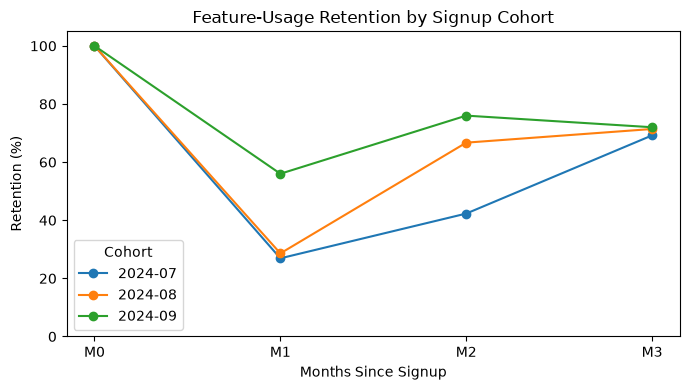

M3 최고: 2024-09 (72.0%)
M3 최저: 2024-07 (69.2%)
차이: 2.8%p


,M1→M2(%p),M2→M3(%p)
cohort,,
2024-07,15.4,26.9
2024-08,38.1,4.8
2024-09,20.0,-4.0


In [4]:
# 필수 2 풀이 코드를 작성하세요.
# 준비 코드의 target, subs, events를 활용하세요.

# ===== 0. 먼저 M3까지 관찰 가능한지 확인 =====
analysis_end_month = analysis_end.to_period("M")
cohort_sizes = target.groupby("cohort")["account_id"].nunique()

observability = pd.DataFrame({"cohort_size": cohort_sizes})
observability["M3_month"] = observability.index + 3
observability["observable_through_M3"] = observability["M3_month"] <= analysis_end_month
display(observability)

# ===== 1. 월별 사용 계정 수 (M1~M3) =====
monthly_users = (
    events.loc[events["month_offset"].between(1, 3)]
    .groupby(["cohort", "month_offset"])["account_id"]
    .nunique()                      # 같은 계정이 여러 번 써도 1개로
    .unstack("month_offset")
    .reindex(columns=[1, 2, 3])
)
monthly_users.columns = ["M1", "M2", "M3"]
# 위에서 세 코호트 모두 M3까지 관찰 가능함을 확인했으므로, 빈 칸은 '관찰했는데 아무도 안 씀'=0이 맞음
monthly_users = monthly_users.fillna(0).astype(int)
display(monthly_users)

# ===== 2. 리텐션 표 (분모는 코호트 가입 계정 수로 고정, M0=100%) =====
retention_raw = monthly_users.div(cohort_sizes, axis=0) * 100
retention_raw.insert(0, "M0", 100.0)
retention = retention_raw.round(1)     # 표시용
display(retention)

# 선그래프
plt.figure(figsize=(7, 4))
for cohort, row in retention.iterrows():
    plt.plot(["M0", "M1", "M2", "M3"], row.values, marker="o", label=str(cohort))
plt.title("Feature-Usage Retention by Signup Cohort")
plt.ylabel("Retention (%)")
plt.xlabel("Months Since Signup")
plt.ylim(0, 105)
plt.legend(title="Cohort")
plt.tight_layout()
plt.show()

# ===== 3. M3 최고·최저와 변화폭 (반올림은 마지막에 한 번만) =====
m3 = retention_raw["M3"]
print(f"M3 최고: {m3.idxmax()} ({m3.max():.1f}%)")
print(f"M3 최저: {m3.idxmin()} ({m3.min():.1f}%)")
print(f"차이: {m3.max() - m3.min():.1f}%p")

change = pd.DataFrame({
    "M1→M2(%p)": (retention_raw["M2"] - retention_raw["M1"]).round(1),
    "M2→M3(%p)": (retention_raw["M3"] - retention_raw["M2"]).round(1),
})
display(change)

### 서술 답안

- 코호트와 M1, M2, M3 : M1(가입 다음 달), M2(가입 다 다음 달), M3(가입 후 세달 뒤)
- 코호트: 같은 시기에 같은 경험을 시작한 집단
- 리텐션이 상승하는 경우: 매월 감소하는 패턴인지? -> 그래프상 아님
- 7월 코호트의 M1->M2는 7개->11개로 늘어서 15.38% 증가  
- 9월 코호트의 M2->M3은 19개->18개로 4% 감소

Q1. 코호트별 가입 계정 수와 M1~M3 실제 사용 계정 수·리텐션은 얼마인가요?  
-> `위 두 표가 각각 고유 계정 수와 고정 가입 분모 기준 비율`  

Q2. M3 리텐션의 최고·최저 코호트와 차이(%p)는 얼마인가요?  
-> `M3의 최고는 2024-09(72%), 최저는 2024-07(69%), 차이는 약 2.7%정도`  

Q3. 변화폭으로 볼 때 매월 감소한다는 가설이 맞나요? 정착 시점을 확정할 수 있나요?  
-> `매월 감소하지 않음(초기 가설이 틀림) 세 코호트 모두 M1->M2상승, 7월과 8월에서는 M2->M3가 상승`  


Q4. 코호트 차이를 제품 개선 효과로 단정할 수 있나요? 추가로 어떤 기록을 확인해야 하나요?  
-> `없음. 기능을 변경했던 이력이나 마케팅, 프로모션 진행 여부 등에 대한 데이터가 없음 <- 추가적으로 확인 필요`

---

## 과제 1 — 개선 우선순위와 개선 시나리오

### 상황

필수 분석 결과를 근거로 실행할 개선안 하나를 제안합니다. 목표 지표는 **가입 월 기능 사용 도달률**입니다. 과제는 필수 수준이며 새로운 분석 기법이나 통계 검정을 요구하지 않습니다.

### 수행 사항

1. 아래 후보의 영향 계정 수와 전체 대상 가입 계정 대비 비율을 계산하세요.
   - A: 가입 월에 구독을 시작하지 않은 계정
   - B: 가입 월에 구독을 시작했지만 가입 월 기능 사용까지 도달하지 않은 계정
   - C: M3 리텐션 최저 코호트 중 M3에 사용하지 않은 계정

2. A·B·C를 교안의 네 기준인 **영향 범위, 목표 지표 연관성, 개선 가능성, 검증 용이성**으로 비교하세요. 영향 범위는 계산값을 적고, 나머지는 이유를 서술합니다. 근거 없는 점수나 상·중·하 등급은 요구하지 않습니다. 후보끼리 중복될 수 있으므로 비율을 합산하지 않습니다.

3. 우선순위 1개를 선택하고, 해당 이슈가 어떤 AARRR 단계에 해당하는지 설명하세요. 선정 근거에는 퍼널과 리텐션의 분석 수치를 함께 사용하세요. 이후 이상 신호, 개선안, 기대 효과, A/B 테스트 아이디어를 작성하세요. 개선안에는 “어떤 원인 때문에 문제가 발생하며, 어떤 변경을 하면 목표 지표가 개선될 것이다”라는 검증 가능한 가설을 포함하세요. 기대 효과는 현재 값과 예상 개선폭·목표값을 제시하되 가정임을 밝히세요.

4. A/B 아이디어에는 대상, A의 기존 경험, B의 변경 경험, 양쪽에 동일하게 적용할 비교 지표의 분자·분모·관찰 기간을 적으세요. 실제 실험 수행·유의성 검정은 하지 않습니다.

5. 가설이 지지되지 않았을 때의 대안 또는 실행 방안의 제약 조건을 한 가지 이상 작성하세요. 대안을 선택하면 다음에 무엇을 바꾸거나 확인할지 설명하고, 제약 조건을 선택하면 인력·일정·개발 자원·데이터 확보 등의 조건이 실행에 어떤 영향을 주는지 설명하세요.

### 질문

Q1. 세 후보의 영향 계정 수와 전체 대상 대비 비율은 얼마인가요?

Q2. 네 가지 기준을 적용하면 무엇을 우선하며, 영향 계정 수만으로 결정하면 안 되는 이유는 무엇인가요?

Q3. 선택한 이슈는 어떤 AARRR 단계에 해당하며, 원인 가설과 네 항목의 개선 시나리오는 무엇인가요?

Q4. 제시한 목표값은 관측 결과인가요, 예상인가요? 원인과 효과를 어떻게 구분했나요?

Q5. 가설이 지지되지 않으면 어떤 대안을 검토하겠나요? 또는 실행 시 어떤 제약 조건을 고려해야 하나요? 둘 중 하나를 선택하여 설명하세요.

### 제출물 / 체크 포인트

과제의 계산 코드·출력, 네 기준 비교표, 퍼널·리텐션 수치에 근거한 우선순위와 AARRR 단계, 원인 가설을 포함한 네 항목의 개선 시나리오, 가설이 지지되지 않을 때의 대안 또는 실행 제약 조건, Q1~Q5 답변을 제출합니다. 필수 1·2는 연습용이며, 과제 판단에 사용한 분석 수치는 과제 답안에도 명시하세요. 정답의 우선순위와 달라도 계산과 목표 지표 연결이 타당하고 검증 가능한 시나리오이면 인정합니다.

In [5]:
# 준비 코드의 target, subs, events, analysis_end를 활용합니다.
# 보완 사항: ① M3 '월말'까지 관찰 가능 여부 확인  ② C의 구성 분해(A·B 중복)
#           ③ C 코호트 내부 비율과 최저 코호트 선정의 불안정성  ④ B의 이후 사용·관찰 창 확인
#           ⑤ 기대 효과 계산(가정 명시)  ⑥ A/B 테스트 표본 규모 개략 추정(Q5 제약 조건 근거)
import math

# ===== 0. 필수 1·2 기준값 재계산 (이 셀만 실행해도 되도록) =====
signup_ids = set(target["account_id"])
total_accounts = len(signup_ids)
cohort_sizes = target.groupby("cohort")["account_id"].nunique()

subs_in_month = subs.loc[
    subs["start_date"].dt.to_period("M") == subs["signup_date"].dt.to_period("M")
]
subscribed_ids = set(subs_in_month["account_id"])
used_ids = set(events.loc[
    (events["month_offset"] == 0)
    & (events["subscription_id"].isin(subs_in_month["subscription_id"])),
    "account_id"
])

# ===== 0-1. M3 '월말'까지 관찰 가능한지 확인 (C 후보의 전제 조건) =====
end_day = analysis_end.normalize()
obs = pd.DataFrame({"cohort_size": cohort_sizes})
obs["M3_month"] = obs.index + 3
obs["M3_month_end"] = obs["M3_month"].dt.to_timestamp(how="end").dt.normalize()
obs["observable_through_M3_end"] = obs["M3_month_end"] <= end_day
print("분석 종료일:", end_day.date())
display(obs)
if not obs["observable_through_M3_end"].all():
    print("⚠ M3 월말까지 관찰되지 않은 코호트가 있습니다. C 후보와 M3 비교는 해석에서 제외하거나 한계로 명시하세요.")

# ===== 0-2. M3 리텐션과 최저 코호트 선정의 안정성 =====
m3_users = (
    events.loc[events["month_offset"] == 3]
    .groupby("cohort")["account_id"].nunique()
    .reindex(cohort_sizes.index, fill_value=0)   # 위에서 관찰 가능 확인 후에만 0이 '미사용'을 뜻함
)
m3 = pd.DataFrame({
    "cohort_size": cohort_sizes,
    "m3_users": m3_users,
    "m3_retention_pct": m3_users / cohort_sizes * 100,
    "one_account_pp": 100 / cohort_sizes,          # 계정 1개가 움직이는 %p
})
display(m3.round(1))

worst_cohort = m3["m3_retention_pct"].idxmin()
ranked = m3["m3_retention_pct"].sort_values()
gap_pp = ranked.iloc[1] - ranked.iloc[0]
print(f"M3 최저 코호트: {worst_cohort} ({ranked.iloc[0]:.1f}%), 2위와 차이 {gap_pp:.1f}%p "
      f"= 최저 코호트 계정 {gap_pp / m3.loc[worst_cohort, 'one_account_pp']:.2f}개 분량")
if gap_pp < m3.loc[worst_cohort, "one_account_pp"]:
    print("→ 차이가 계정 1개 미만이라 최저 코호트 선정이 불안정함 (C의 약점으로 기록)")

# ===== 1. 후보 A·B·C의 영향 계정 수와 비율 =====
A_ids = signup_ids - subscribed_ids                                    # 가입 월 구독 미시작
B_ids = subscribed_ids - used_ids                                      # 구독했으나 가입 월 기능 미사용
worst_ids = set(target.loc[target["cohort"] == worst_cohort, "account_id"])
m3_used_ids = set(events.loc[events["month_offset"] == 3, "account_id"])
C_ids = worst_ids - m3_used_ids                                        # 최저 코호트 중 M3 미사용

candidates = pd.DataFrame({
    "candidate": ["A: 가입 월 구독 미시작",
                  "B: 구독했으나 가입 월 기능 미사용",
                  f"C: {worst_cohort} 코호트 중 M3 미사용"],
    "accounts": [len(A_ids), len(B_ids), len(C_ids)],
})
candidates["ratio"] = candidates["accounts"].astype(str) + "/" + str(total_accounts)
candidates["share_of_total_pct"] = (candidates["accounts"] / total_accounts * 100).round(1)
candidates["share_within_cohort_pct"] = [None, None, round(len(C_ids) / len(worst_ids) * 100, 1)]
display(candidates)

# ===== 1-1. 중복 관계와 C의 구성 분해 (비율을 합산하지 않는 근거) =====
C_in_A = C_ids & A_ids
C_in_B = C_ids & B_ids
C_used_m0 = C_ids & used_ids                                           # 가입 월에는 사용했으나 M3 미사용
assert len(A_ids & B_ids) == 0
assert len(C_in_A) + len(C_in_B) + len(C_used_m0) == len(C_ids)
print(f"A∩B: {len(A_ids & B_ids)}개")
print(f"C {len(C_ids)}개 = A와 중복 {len(C_in_A)}개 + B와 중복 {len(C_in_B)}개 "
      f"+ 가입 월 사용 후 M3 미사용 {len(C_used_m0)}개")

# ===== 2. 네 기준 비교용 수치 근거 =====
one_account_reach_pp = 100 / total_accounts          # 목표 지표에서 계정 1개의 무게

def later_users(ids, offsets=(1, 2, 3)):
    """ids 중 M1~M3에 실제 사용한 계정 (가입 월 이후에라도 사용했는지)"""
    return set(events.loc[events["month_offset"].isin(offsets)
                          & events["account_id"].isin(ids), "account_id"])

A_later, B_later = later_users(A_ids), later_users(B_ids)
criteria_numbers = pd.DataFrame({
    "후보": ["A", "B", "C"],
    "영향 계정 수": [len(A_ids), len(B_ids), len(C_ids)],
    "전체 대비(%)": candidates["share_of_total_pct"].values,
    "목표 지표 반영까지 필요한 단계": ["구독 시작 + 기능 사용(2단계)", "기능 사용(1단계)", "해당 없음(M3는 가입 월 이후)"],
    "결과 확인까지 관찰 개월": [0, 0, 3],
    "M1~M3에 사용한 계정": [f"{len(A_later)}/{len(A_ids)}", f"{len(B_later)}/{len(B_ids)}", "-"],
})
display(criteria_numbers)
print(f"목표 지표에서 계정 1개 전환 = {one_account_reach_pp:.1f}%p")

# ===== 2-1. B의 관찰 창 확인 (월말 구독으로 가입 월 관찰이 짧았는지) =====
first_sub_B = (subs_in_month[subs_in_month["account_id"].isin(B_ids)]
               .sort_values("start_date").groupby("account_id").first())
month_end_B = first_sub_B["signup_date"].dt.to_period("M").dt.to_timestamp(how="end").dt.normalize()
days_left_B = (month_end_B - first_sub_B["start_date"].dt.normalize()).dt.days + 1
print("\nB 계정의 구독 시작일 → 가입 월 말일까지 남은 일수:")
print(days_left_B.describe().round(1).to_string())
print(f"관찰 7일 이하인 B 계정: {(days_left_B <= 7).sum()}/{len(days_left_B)}")

# B 계정의 첫 사용 월 분포 (첫 사용이 늦어지는 것인지)
first_use_B = (events[events["account_id"].isin(B_ids)]
               .groupby("account_id")["month_offset"].min())
print("\nB 계정의 첫 사용 month_offset 분포 (없으면 관찰 기간 내 미사용):")
print(first_use_B.value_counts().sort_index().to_string())
print("관찰 기간 내 한 번도 사용하지 않은 B 계정:", len(B_ids) - len(first_use_B))

# ===== 3. 기대 효과 (가정) =====
current_step = len(used_ids) / len(subscribed_ids)
current_reach = len(used_ids) / total_accounts
ASSUMED_STEP_CONV = 0.25   # ← 가정값: 구독→사용 전환율 목표. 근거를 답안에 서술할 것
assert ASSUMED_STEP_CONV > current_step, "가정 목표치가 현재 전환율보다 커야 개선 시나리오가 됩니다."
expected_users = round(len(subscribed_ids) * ASSUMED_STEP_CONV)
expected_reach = expected_users / total_accounts
print(f"\n[관측] 구독→사용 {len(used_ids)}/{len(subscribed_ids)} = {current_step*100:.1f}%, "
      f"가입 월 도달률 {len(used_ids)}/{total_accounts} = {current_reach*100:.1f}%")
print(f"[가정] 구독→사용 {ASSUMED_STEP_CONV*100:.0f}% → 사용 계정 {expected_users}개 → "
      f"도달률 {expected_users}/{total_accounts} = {expected_reach*100:.1f}% "
      f"(+{(expected_reach - current_reach)*100:.1f}%p)")

# ===== 4. A/B 테스트 표본 규모 개략 추정 (Q5 제약 조건 근거, 검정 수행 아님) =====
# 두 비율 비교의 정규근사 공식, 유의수준 5%(양측), 검정력 80% 가정
z_a, z_b = 1.96, 0.8416
p1, p2 = current_step, ASSUMED_STEP_CONV
n_per_group = math.ceil((z_a + z_b) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2)) / (p2 - p1) ** 2)
monthly_subscribers = len(subscribed_ids) / cohort_sizes.size
months_needed = 2 * n_per_group / monthly_subscribers
print(f"\n[개략 추정] 그룹당 필요 표본 약 {n_per_group}개, 두 그룹 {2*n_per_group}개")
print(f"현재 월평균 가입 월 구독 시작 계정 {monthly_subscribers:.1f}개 기준 약 {months_needed:.1f}개월 소요")

분석 종료일: 2024-12-31


,cohort_size,M3_month,M3_month_end,observable_through_M3_end
cohort,,,,
2024-07,26,2024-10,2024-10-31,True
2024-08,21,2024-11,2024-11-30,True
2024-09,25,2024-12,2024-12-31,True


,cohort_size,m3_users,m3_retention_pct,one_account_pp
cohort,,,,
2024-07,26,18,69.2,3.8
2024-08,21,15,71.4,4.8
2024-09,25,18,72.0,4.0


M3 최저 코호트: 2024-07 (69.2%), 2위와 차이 2.2%p = 최저 코호트 계정 0.57개 분량
→ 차이가 계정 1개 미만이라 최저 코호트 선정이 불안정함 (C의 약점으로 기록)


,candidate,accounts,ratio,share_of_total_pct,share_within_cohort_pct
0,A: 가입 월 구독 미시작,20,20/72,27.8,NaN
1,B: 구독했으나 가입 월 기능 미사용,47,47/72,65.3,NaN
2,C: 2024-07 코호트 중 M3 미사용,8,8/72,11.1,30.8


A∩B: 0개
C 8개 = A와 중복 4개 + B와 중복 3개 + 가입 월 사용 후 M3 미사용 1개


,후보,영향 계정 수,전체 대비(%),목표 지표 반영까지 필요한 단계,결과 확인까지 관찰 개월,M1~M3에 사용한 계정
0,A,20,27.8,구독 시작 + 기능 사용(2단계),0,15/20
1,B,47,65.3,기능 사용(1단계),0,44/47
2,C,8,11.1,해당 없음(M3는 가입 월 이후),3,-


목표 지표에서 계정 1개 전환 = 1.4%p

B 계정의 구독 시작일 → 가입 월 말일까지 남은 일수:
count    47.0
mean     10.1
std       7.5
min       1.0
25%       5.0
50%       9.0
75%      13.0
max      27.0
관찰 7일 이하인 B 계정: 21/47

B 계정의 첫 사용 month_offset 분포 (없으면 관찰 기간 내 미사용):
month_offset
1    20
2    17
3     7
4     1
관찰 기간 내 한 번도 사용하지 않은 B 계정: 2

[관측] 구독→사용 5/52 = 9.6%, 가입 월 도달률 5/72 = 6.9%
[가정] 구독→사용 25% → 사용 계정 13개 → 도달률 13/72 = 18.1% (+11.1%p)

[개략 추정] 그룹당 필요 표본 약 91개, 두 그룹 182개
현재 월평균 가입 월 구독 시작 계정 17.3개 기준 약 10.5개월 소요


### 서술 답안

**Q1. 세 후보의 영향 계정 수와 전체 대상 대비 비율은 얼마인가요?**  
   - A (가입 월에 구독을 시작하지 않은 계정) : 20개 (27.8%)
   - B (가입 월에 구독을 시작했지만 가입 월 기능 사용까지 도달하지 않은 계정) : 47개 (65.3%)
   - C (M3 리텐션 최저 코호트 중 M3에 사용하지 않은 계정) : 8개 (11.1%)


**Q2. 네 가지 기준을 적용하면 무엇을 우선하며, 영향 계정 수만으로 결정하면 안 되는 이유는 무엇인가요?**  
- `영향 범위 : 문제에 해당하는 대상이 얼마나 많은지 보는 기준`  
-> B : 47개 계정(전체 72개의 65.3%)으로 세 후보 중 가장 많이 차지하여 우선시함  
-> (A: 20개, 27.8% / C: 8개, 11.1%)

- `목표 지표 연관성: 목표 지표와 얼마나 연관성이 있는지 보는 기준`  
-> B: 47개 계정은 이미 가입 월 안에 구독을 시작한 상태, 사용 한 번만 하면 1개 계정이 전환될 때마다 도달률이 1.4%p(1/72)올라 분자와 직접 연결되어있어 우선시함  
-> (A: 구독→사용 두 단계를 거침 -> 20개를 전부 구독시켜도 약 1.9개만 분자에 추가됨(+2.7%p))  
-> (C: M3 시점을 보는 집단, 가입 월과 시점 자체가 달라 8개를 전부 개선해도 변화가 0%p)  

- `개선 가능성: 원인에 개입할 지점이 있고, 실제로 행동을 바꿀 여지가 있는지 보는 기준`  
-> B: 47개 중 44개(93.6%)가 M1~M3에 사용  
첫 사용이 M1(20개)·M2(17개)에 몰려 있어 첫 사용 시점을 앞당기는 개입이 가능한 대상으로 파악하여 우선시함  
-> (A: 20개 중 15개(75.0%)가 M1~M3에 사용하나, 가입 월에 구독을 시작하지 않은 이유가 데이터에 없어 개입 시점을 특정하기 어렵고, 구독과 사용 두 행동을 함께 관찰해야 함)  
-> (C : 8개 중 4개는 A, 3개는 B와 겹쳐 C에만 해당하는 고유 계정은 1개로 C를 개선 대상으로 선정해도 얻는 대상은 1개임)  

- `검증 용이성: 개선 효과를 얼마나 빠르고 명확하게 확인할 수 있는지 보는 기준`  
-> B: 분모(가입 월 구독 시작 계정)와 분자(가입 월 말까지 실제 사용 계정)가 명확하고, 가입 월 말이면 결과 확인 가능  
-> (A: 결과 확인 시점은 B와 같지만 구독과 사용 두 단계를 함께 봐야 하고, 목표 지표 증가폭이 +2.7%p 수준으로 작아 차이를 확인하려면 B보다 더 많은 표본이 필요함)  
-> (C: 대상이 8개로 가장 적고, M3까지 최소 3개월을 추가로 관찰해야함)

- `결론: B: 네 기준 모두 부합`  
대상이 47개(65.3%)로 가장 많음  
목표 지표의 분자에 직접 연결  
첫 사용 시점을 앞당기는 개입이 가능한 대상  
가입 월 말이면 결과 확인 가능

- `영향 계정 수만으로 정하면 안 되는 이유`  
영향 계정 수는 문제가 얼마나 넓게 퍼져 있는지만 보여주고 그 문제를 해결했을 때 목표 지표가 얼마나 움직이는지는 알려주지 않음  
대상이 많아도 원인을 모르거나 개입할 방법이 없으면 개선할 수 없고, 효과를 확인하는 데 오래 걸리면 실행 판단이 늦어짐  


**Q3. 선택한 이슈는 어떤 AARRR 단계에 해당하며, 원인 가설과 네 항목의 개선 시나리오는 무엇인가요?**  
- Activation(활성화) : 가입과 구독은 마쳤지만 핵심인 기능 사용(활성화)에 도달하지 못함  
(Retention은 이미 활성화된 사용자의 재방문을 보는데, 47개 계정은 아직 첫 사용조차 하지 않아 그 이전 단계에 해당)

`원인 가설`  
- 구독 시작 직후 첫 기능 사용으로 이어지는 안내가 부족해 첫 사용이 다음 달 이후로 미뤄지는 것 일것이다.  

`이상 신호`  
- 가입 월에 구독을 시작한 52개 계정 중 같은 달에 기능을 사용한 계정은 5개(9.6%)로 퍼널에서 가장 낮은 구간이며, 가입 월 도달률은 6.9%(5/72).  
반면 미도달 B 47개 중 44개가 M1~M3에 사용 -> 첫 사용이 M1(20개)·M2(17개)에 집중됨. 리텐션도 M1 26.9~56.0%에서 M3 69.2~72.0%로 상승.  
-> 사용 자체가 아니라 첫 사용 시점이 늦어지는 이상 신호로 파악  

`개선안`  
- 구독을 시작한 직후 무엇부터 사용해야 하는지 안내가 없어, 사용 의향이 있는 계정도 첫 기능 사용을 다음 달 이후로 미루는 문제가 발생하며,  
구독 완료 직후 대표 기능 하나를 바로 실행하도록 안내하면(첫 사용 시점을 앞당기는 방향) 가입 월 기능 사용 도달률이 개선될 것이다.

`근거`  
- 구독 시작 52개 계정 중 가입 월 사용은 5개(9.6%)로 퍼널에서 가장 낮은 구간  
-> 하지만 미도달 B 47개 중 44개(93.6%)가 M1~M3에 사용했고, 첫 사용이 M1(20개)·M2(17개)에 집중되어있는 것으로 파악  
-> 사용 의향은 있으나 첫 사용 시점이 늦어지는 것으로 판단  

`기대효과`  
현재(관측): 구독→가입 월 사용 전환율 9.6%(5/52), 가입 월 기능 사용 도달률 6.9%(5/72)  
목표(가정): 전환율 25%로 개선 시 사용 계정 13개(+8개), 도달률 18.1%(13/72, +11.1%p)  
-> 추가 8개는 M1에 처음 사용한 B 계정 20개의 40%로, 이미 사용한 계정의 첫 사용을 가입 월로 앞당기는 수준으로 가정 (관측값 아님, A/B 테스트로 확인 필요)

`A/B 테스트 아이디어`  
- 대상: 가입 월에 구독을 시작한 신규 계정, 구독 시작 시점에 A,B로 무작위 배정  
- A (기존): 현재와 동일하게 구독 완료 후 별도 안내 없이 기존 경로로 기능 사용  
- B (변경): 구독 완료 화면에서 대표 기능 1개를 바로 실행할 수 있는 첫 실행 안내 제공  
- 비교 지표: 구독→가입 월 사용 전환율  
  -> 분자: 구독 시작 후 가입 월 말까지 실제 사용(`usage_count > 0`)한 계정 수  
  -> 분모: 해당 그룹의 구독 시작 계정 수  
  -> 관찰 기간: 가입 월 말까지 (A,B 동일)  
- 보조 지표:  
  -> 구독 후 7일 이내 첫 사용 비율: 월말 구독으로 관찰 기간이 짧아지는 영향 없이 모든 계정을 같은 기간으로 비교  
  -> 구독 후 첫 사용까지 걸린 일수(중앙값): 첫 사용이 실제로 앞당겨졌는지 확인  
  -> M1 사용률: 첫 사용만 앞당기고 이후 사용은 줄어드는 부작용이 없는지 확인  
  -> 안내 노출 대비 클릭 비율(B만): 안내를 통해 발생했는지 효과 확인, 현재 데이터에 없어 실험 시 새로 기록

**Q4. 제시한 목표값은 관측 결과인가요, 예상인가요? 원인과 효과를 어떻게 구분했나요?**  
`목표값: 예상(가정)`  
-> 관측값: 구독→가입 월 사용 전환율 9.6%(5/52), 도달률 6.9%(5/72), 미도달 B 47개 중 44개가 M1~M3에 사용, 첫 사용 M1 20개·M2 17개  
-> 예상값: 전환율 25%, 도달률 18.1%(13/72)는 M1 첫 사용 계정 20개 중 40%를 앞당긴다는 가정에서 계산한 값 (관측 결과X)  

`원인과 효과의 구분`  
-> 데이터로 확인 : B 계정 대부분이 가입 월 이후에 첫 사용  
-> 확인 못한 원인: "구독 직후 안내가 부족해서"는 화면 조회·온보딩 이벤트등이 없어 아직 검증할 수 없는 가설, 월말 구독으로 관찰 기간이 짧았을 가능성(B의 21/47이 7일 이하)도 있을 수 있음  
-> 효과: 안내를 제공하면 도달률이 오른다는 것은 A/B 테스트로 비교하여 확인

**Q5. 가설이 지지되지 않으면 어떤 대안을 검토하겠나요? 또는 실행 시 어떤 제약 조건을 고려해야 하나요? 둘 중 하나를 선택하여 설명하세요.**  
- `대안 검토`  
B 그룹 전환율이 A 그룹과 차이가 없다면 원인이 안내 부족이 아닌, 월 말 구독으로 가입 월 관찰 기간이 짧았던 가능성도 검토해보는 방향을 고려  
(B의 44/47이 이후 사용, 21/47은 가입 월 관찰 7일 이하였기 때문)  
구독 시작일부터 첫 사용까지 소요 일수를 확인, 필요하면 목표 지표를 "구독 후 30일 이내 첫 사용 비율"처럼 모든 계정에 같은 관찰 기간을 주는 지표로 변경  
-> 구독 시작일이 월 전반·후반인 계정, plan_tier·seats 등 계정 속성별로 전환율을 나눠 지연이 특정 조건에서만 나타나는지 검토

---

## 실습 마무리

- 어떤 분석 문제가 있었는가?  
-> 신규 계정 가입 월 기능 사용 도달과 반복(재구매율)을 보았음.  
- 어떤 분석적 방법을 적용했는가?  
-> 퍼널(이전 단계 전환율, 가입 월 코호트 리텐션)  
- 무엇을 근거로 결론을 내렸는가?  
-> 실제 계정 수와 비율, 그래프로 개선 가능성 확인